<a href="https://colab.research.google.com/github/Musfik14/SMR-project1/blob/main/2nd_try_with_full_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ======================================================
# FR_00_BOOTSTRAP_SSD (RUN ONCE per new runtime)
# - SSD-only experiment root
# - Download ASVspoof2019 to SSD
# - Create run folders on SSD
# ======================================================

!pip -q install kagglehub==0.2.9

import os, time, json, shutil
import torch
import kagglehub

# ---- SSD ROOTS ----
SSD_ROOT   = "/content/asvspoof_project"
RUNS_ROOT  = os.path.join(SSD_ROOT, "runs")
DATA_DIR   = "/content/ASVspoof2019_RAW"     # SSD dataset location

os.makedirs(RUNS_ROOT, exist_ok=True)

# ---- NEW RUN (SSD ONLY) ----
RUN_ID  = time.strftime("run_%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(RUNS_ROOT, RUN_ID)

DIRS = {
    "run": RUN_DIR,
    "ckpt": os.path.join(RUN_DIR, "checkpoints"),
    "feat": os.path.join(RUN_DIR, "features"),
    "scores": os.path.join(RUN_DIR, "scores"),
    "meta": os.path.join(RUN_DIR, "meta"),
    "logs": os.path.join(RUN_DIR, "logs"),
}
for p in DIRS.values():
    os.makedirs(p, exist_ok=True)

# ---- Download dataset to SSD ----
src_path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")
if not os.path.exists(DATA_DIR):
    shutil.copytree(src_path, DATA_DIR)

# ---- GPU check ----
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ---- Save minimal config (SSD) ----
CFG = {
    "run_id": RUN_ID,
    "ssd_root": SSD_ROOT,
    "data_dir": DATA_DIR,
    "dirs": DIRS,
    "protocols": ["LA", "PA"],
    "seed": 42,
}
with open(os.path.join(DIRS["meta"], "config.json"), "w") as f:
    json.dump(CFG, f, indent=2)

print("RUN_ID:", RUN_ID)
print("RUN_DIR:", RUN_DIR)
print("DATA_DIR:", DATA_DIR)
print("Config:", os.path.join(DIRS["meta"], "config.json"))


100%|██████████| 23.6G/23.6G [05:04<00:00, 83.2MB/s]


Extracting model files...
CUDA available: False
RUN_ID: run_20251229_185216
RUN_DIR: /content/asvspoof_project/runs/run_20251229_185216
DATA_DIR: /content/ASVspoof2019_RAW
Config: /content/asvspoof_project/runs/run_20251229_185216/meta/config.json


In [2]:
# ======================================================
# FR_01_INSTALL (locked deps)
# ======================================================

!pip install -q \
    torch==2.1.2 \
    librosa==0.10.1 \
    soundfile==0.12.1 \
    numpy==1.24.4 \
    scipy==1.11.4 \
    matplotlib==3.8.2 \
    scikit-learn==1.3.2 \
    pandas==2.1.4 \
    tqdm==4.66.1

print("FR_01 completed.")


ERROR: Could not find a version that satisfies the requirement torch==2.1.2 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1)
ERROR: No matching distribution found for torch==2.1.2
FR_01 completed.


In [3]:
# ======================================================
# FR_02_PROTOCOLS (LA+PA train/dev index)
# ======================================================
import os
import pandas as pd

def find_file(root, name):
    for r, _, f in os.walk(root):
        if name in f:
            return os.path.join(r, name)
    raise FileNotFoundError(name)

def load_proto(proto, split):
    base = os.path.join(DATA_DIR, proto)
    fname = {
        "train": f"ASVspoof2019.{proto}.cm.train.trn.txt",
        "dev":   f"ASVspoof2019.{proto}.cm.dev.trl.txt",
    }[split]
    path = find_file(base, fname)
    df = pd.read_csv(path, sep=" ", header=None)
    df = df[[1, 4]]
    df.columns = ["file_id", "label"]
    df["label"] = df["label"].map({"bonafide": 0, "spoof": 1})
    df["proto"] = proto
    return df

train_df = pd.concat([load_proto("LA","train"), load_proto("PA","train")]).reset_index(drop=True)
dev_df   = pd.concat([load_proto("LA","dev"),   load_proto("PA","dev")]).reset_index(drop=True)

print("Train distribution:\n", train_df.label.value_counts(normalize=True))
print("Dev distribution:\n", dev_df.label.value_counts(normalize=True))
print("FR_02 done.")


Train distribution:
 label
1    0.899471
0    0.100529
Name: proportion, dtype: float64
Dev distribution:
 label
1    0.854283
0    0.145717
Name: proportion, dtype: float64
FR_02 done.


In [4]:
# ======================================================
# FR_03_BALANCE (Weighted sampler)
# ======================================================
import numpy as np
from torch.utils.data import WeightedRandomSampler

labels = train_df["label"].values
class_counts = np.bincount(labels)          # [bonafide, spoof]
class_weights = 1.0 / class_counts
sample_weights = class_weights[labels]

print("Class counts:", class_counts)
print("Class weights:", class_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("FR_03 done.")


Class counts: [ 7980 71400]
Class weights: [1.25313283e-04 1.40056022e-05]
FR_03 done.


In [5]:
# ======================================================
# FR_04_FEATURE_PLAN (SSD paths + params)
# ======================================================
import os, json

MEL_CACHE_DIR = os.path.join(DIRS["feat"], "logmel")      # SSD
CUE_CACHE_DIR = os.path.join(DIRS["feat"], "cues")        # SSD

os.makedirs(MEL_CACHE_DIR, exist_ok=True)
os.makedirs(CUE_CACHE_DIR, exist_ok=True)

FCFG = {
    "sr": 16000,
    "n_mels": 80,
    "n_fft": 1024,
    "hop": 160,
    "win": 400,
    "cue_dim": 9
}

with open(os.path.join(DIRS["meta"], "feature_config.json"), "w") as f:
    json.dump(FCFG, f, indent=2)

print("FR_04 done.")
print("Log-mel cache:", MEL_CACHE_DIR)
print("Cue cache:", CUE_CACHE_DIR)


FR_04 done.
Log-mel cache: /content/asvspoof_project/runs/run_20251229_185216/features/logmel
Cue cache: /content/asvspoof_project/runs/run_20251229_185216/features/cues


In [6]:
# ======================================================
# FR_05_LOGMEL (extract to SSD)
# ======================================================
import os, json, warnings
import numpy as np
import librosa
from tqdm import tqdm

warnings.filterwarnings("ignore")

with open(os.path.join(DIRS["meta"], "feature_config.json"), "r") as f:
    FCFG = json.load(f)

SR, N_M, N_F, HOP, WIN = FCFG["sr"], FCFG["n_mels"], FCFG["n_fft"], FCFG["hop"], FCFG["win"]

def audio_path(file_id, proto, split):
    return os.path.join(
        DATA_DIR, proto, proto,
        f"ASVspoof2019_{proto}_{split}",
        "flac",
        f"{file_id}.flac"
    )

def extract_logmel(path):
    y, _ = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_F,
        hop_length=HOP, win_length=WIN,
        n_mels=N_M
    )
    return librosa.power_to_db(mel).astype(np.float32)

def run_logmel(df, split):
    failures = 0
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"LogMel {split}"):
        out_dir = os.path.join(MEL_CACHE_DIR, r.proto, split)
        os.makedirs(out_dir, exist_ok=True)

        out = os.path.join(out_dir, r.file_id + ".npy")
        if os.path.exists(out):
            continue

        ap = audio_path(r.file_id, r.proto, split)
        if not os.path.exists(ap):
            failures += 1
            continue

        try:
            feat = extract_logmel(ap)
            np.save(out, feat)
        except:
            failures += 1

    print(f"[LogMel {split}] failures:", failures)

run_logmel(train_df, "train")
run_logmel(dev_df, "dev")

print("FR_05 done.")


LogMel train: 100%|██████████| 79380/79380 [1:29:59<00:00, 14.70it/s]


[LogMel train] failures: 0


LogMel dev: 100%|██████████| 54544/54544 [51:50<00:00, 17.54it/s]


[LogMel dev] failures: 0
FR_05 done.


In [7]:
# ======================================================
# FR_06_CUES (extract to SSD)
# ======================================================
import os, json, warnings
import numpy as np
import librosa
from tqdm import tqdm
from scipy.stats import skew

warnings.filterwarnings("ignore")

with open(os.path.join(DIRS["meta"], "feature_config.json"), "r") as f:
    FCFG = json.load(f)

SR, N_F, HOP = FCFG["sr"], FCFG["n_fft"], FCFG["hop"]

def audio_path(file_id, proto, split):
    return os.path.join(
        DATA_DIR, proto, proto,
        f"ASVspoof2019_{proto}_{split}",
        "flac",
        f"{file_id}.flac"
    )

def extract_cues(path):
    y, _ = librosa.load(path, sr=SR)

    S = np.abs(librosa.stft(y, n_fft=N_F, hop_length=HOP))
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0))

    D = librosa.stft(y, n_fft=N_F, hop_length=HOP)
    phase = np.unwrap(np.angle(D), axis=1)
    pd = np.mean(np.abs(np.diff(phase, axis=1)), axis=0)

    rms = librosa.feature.rms(y=y, hop_length=HOP)[0]

    return np.array([
        flux.mean(), flux.std(), flux.max(), np.percentile(flux, 95),
        pd.mean(), pd.std(), skew(pd),
        rms.mean(), rms.std()
    ], dtype=np.float32)

def run_cues(df, split):
    failures = 0
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f"Cues {split}"):
        out_dir = os.path.join(CUE_CACHE_DIR, r.proto, split)
        os.makedirs(out_dir, exist_ok=True)

        out = os.path.join(out_dir, r.file_id + ".npz")
        if os.path.exists(out):
            continue

        ap = audio_path(r.file_id, r.proto, split)
        if not os.path.exists(ap):
            failures += 1
            continue

        try:
            cue = extract_cues(ap)
            np.savez(out, cue=cue)
        except:
            failures += 1

    print(f"[Cues {split}] failures:", failures)

run_cues(train_df, "train")
run_cues(dev_df, "dev")

print("FR_06 done. Cue dim =", FCFG["cue_dim"])


Cues train: 100%|██████████| 79380/79380 [1:34:25<00:00, 14.01it/s]


[Cues train] failures: 0


Cues dev: 100%|██████████| 54544/54544 [56:25<00:00, 16.11it/s]

[Cues dev] failures: 0
FR_06 done. Cue dim = 9


In [8]:
# ======================================================
# FR_07_DATASET (SSD cached HybridDataset + collate)
# ======================================================
import os, json, numpy as np, torch
from torch.utils.data import Dataset
import torch.nn.functional as F

with open(os.path.join(DIRS["meta"], "feature_config.json"), "r") as f:
    FCFG = json.load(f)

class HybridDataset(Dataset):
    def __init__(self, df, split):
        self.df = df.reset_index(drop=True)
        self.split = split

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]

        mel_path = os.path.join(MEL_CACHE_DIR, r.proto, self.split, r.file_id + ".npy")
        cue_path = os.path.join(CUE_CACHE_DIR, r.proto, self.split, r.file_id + ".npz")

        if not os.path.exists(mel_path):
            raise FileNotFoundError(mel_path)
        if not os.path.exists(cue_path):
            raise FileNotFoundError(cue_path)

        mel = torch.tensor(np.load(mel_path), dtype=torch.float32).unsqueeze(0)
        cue = torch.tensor(np.load(cue_path)["cue"], dtype=torch.float32)
        lab = torch.tensor(r.label, dtype=torch.float32)

        return mel, cue, lab

def collate_pad(batch):
    mels, cues, labels = zip(*batch)
    T = max(m.shape[-1] for m in mels)
    mels = [F.pad(m, (0, T - m.shape[-1])) for m in mels]
    return torch.stack(mels), torch.stack(cues), torch.stack(labels).unsqueeze(1)

print("FR_07 done.")


FR_07 done.


In [9]:
# ======================================================
# FR_08A_MODEL_DEF (same style as your baseline)
# ======================================================
import torch
import torch.nn as nn

class LightCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(32, 16)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class CueMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )

    def forward(self, x):
        return self.net(x)

class FusionNet(nn.Module):
    def __init__(self, cue_dim):
        super().__init__()
        self.cnn = LightCNN()
        self.cue = CueMLP(cue_dim)
        self.classifier = nn.Linear(16 + 8, 1)

    def forward(self, mel, cue):
        f_mel = self.cnn(mel)
        f_cue = self.cue(cue)
        fused = torch.cat([f_mel, f_cue], dim=1)
        return torch.sigmoid(self.classifier(fused))

print("FR_08A done: FusionNet ready.")


FR_08A done: FusionNet ready.


In [10]:
# ======================================================
# FR_09_LOADERS (SSD + balanced sampler)
# ======================================================
import torch
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = HybridDataset(train_df, "train")
dev_ds   = HybridDataset(dev_df, "dev")

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    sampler=train_sampler,
    num_workers=0,
    collate_fn=collate_pad
)

dev_loader = DataLoader(
    dev_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_pad
)

print("FR_09 done: loaders ready.")


FR_09 done: loaders ready.


In [ ]:
# ======================================================
# FR_10_TRAIN_FRESH (SSD checkpoints each epoch)
# ======================================================
import os
import torch
import torch.optim as optim
from tqdm import tqdm

model = FusionNet(cue_dim=FCFG["cue_dim"]).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.BCELoss()

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for mel, cue, y in pbar:
        mel, cue, y = mel.to(DEVICE), cue.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(mel, cue)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    ckpt_path = os.path.join(DIRS["ckpt"], f"{RUN_ID}_epoch{epoch+1}.pt")
    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "run_id": RUN_ID
    }, ckpt_path)

    print("✔ Saved:", ckpt_path)

print("FR_10 done: training complete.")


In [12]:
# ======================================================
# FR_10_VALIDATE_BACKUP: Validate + backup to Drive
# ======================================================
import os, torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_curve

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- DRIVE BACKUP ROOT ----------
DRIVE_BACKUP = "/content/drive/MyDrive/asvspoof_project_backups"
os.makedirs(DRIVE_BACKUP, exist_ok=True)

RUN_BACKUP_DIR = os.path.join(DRIVE_BACKUP, RUN_ID)
os.makedirs(RUN_BACKUP_DIR, exist_ok=True)

# ---------- LOAD LATEST CHECKPOINT (SSD) ----------
ckpts = sorted([
    f for f in os.listdir(DIRS["ckpt"])
    if f.startswith(RUN_ID) and f.endswith(".pt")
])
latest_ckpt = os.path.join(DIRS["ckpt"], ckpts[-1])
print("Using checkpoint:", latest_ckpt)

ckpt = torch.load(latest_ckpt, map_location=DEVICE)

# ---------- REBUILD MODEL ----------
model = FusionNet(cue_dim=FCFG["cue_dim"]).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

# ---------- DEV LOADER ----------
from torch.utils.data import DataLoader

dev_loader = DataLoader(
    HybridDataset(dev_df, "dev"),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_pad
)

# ---------- VALIDATION ----------
scores = []
labels = []

with torch.no_grad():
    for mel, cue, y in tqdm(dev_loader, desc="Validating"):
        mel, cue = mel.to(DEVICE), cue.to(DEVICE)
        out = model(mel, cue).squeeze(1).cpu().numpy()
        scores.extend(out)
        labels.extend(y.numpy())

# ---------- SAVE SCORES ----------
score_df = dev_df.copy()
score_df["score"] = scores

score_path = os.path.join(DIRS["scores"], f"{RUN_ID}_dev_scores.csv")
score_df.to_csv(score_path, index=False)

# ---------- METRICS ----------
y_true = np.array(labels)
y_score = np.array(scores)

fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
fnr = 1 - tpr
eer = np.mean([fpr[np.argmin(abs(fpr - fnr))],
               fnr[np.argmin(abs(fpr - fnr))]])

# simplified ASVspoof 2019 constants
P_tar, P_non, P_spoof = 0.9801, 0.0099, 0.0100
C_miss, C_fa, C_fa_spoof = 1, 10, 10

tDCF = C_miss * P_tar * fnr + C_fa * P_non * fpr + C_fa_spoof * P_spoof * fpr
min_tdcf = np.min(tDCF)

print(f"✅ EER = {eer*100:.2f} %")
print(f"✅ min-tDCF = {min_tdcf:.4f}")

# ---------- SAVE METADATA ----------
metrics = {
    "epoch": ckpt["epoch"],
    "EER": float(eer),
    "min_tDCF": float(min_tdcf)
}

metrics_path = os.path.join(DIRS["meta"], f"{RUN_ID}_metrics.json")
pd.Series(metrics).to_json(metrics_path, indent=2)

# ---------- BACKUP TO GOOGLE DRIVE ----------
import shutil

shutil.copy(latest_ckpt, RUN_BACKUP_DIR)
shutil.copy(score_path, RUN_BACKUP_DIR)
shutil.copy(metrics_path, RUN_BACKUP_DIR)

print("📦 Backup completed to Google Drive:")
print(RUN_BACKUP_DIR)


Using checkpoint: /content/asvspoof_project/runs/run_20251229_185216/checkpoints/run_20251229_185216_epoch2.pt


Validating: 100%|██████████| 1705/1705 [38:36<00:00,  1.36s/it]


✅ EER = 26.02 %
✅ min-tDCF = 0.1957
📦 Backup completed to Google Drive:
/content/drive/MyDrive/asvspoof_project_backups/run_20251229_185216


In [16]:
# ======================================================
# FR_12_METRICS (EER + simplified min-tDCF)
# ======================================================
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

score_path = os.path.join(DIRS["scores"], f"{RUN_ID}_dev_scores.csv")
df = pd.read_csv(score_path)

y_true = df["label"].values
y_score = df["score"].values

fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
print(f"✅ EER = {eer*100:.2f} %")

P_tar, P_non, P_spoof = 0.9801, 0.0099, 0.0100
C_miss, C_fa, C_fa_spoof = 1, 10, 10

tDCF = (
    C_miss * P_tar * fnr +
    C_fa * P_non * fpr +
    C_fa_spoof * P_spoof * fpr
)

print(f"✅ min-tDCF = {np.min(tDCF):.4f}")


✅ EER = 26.02 %
✅ min-tDCF = 0.1957


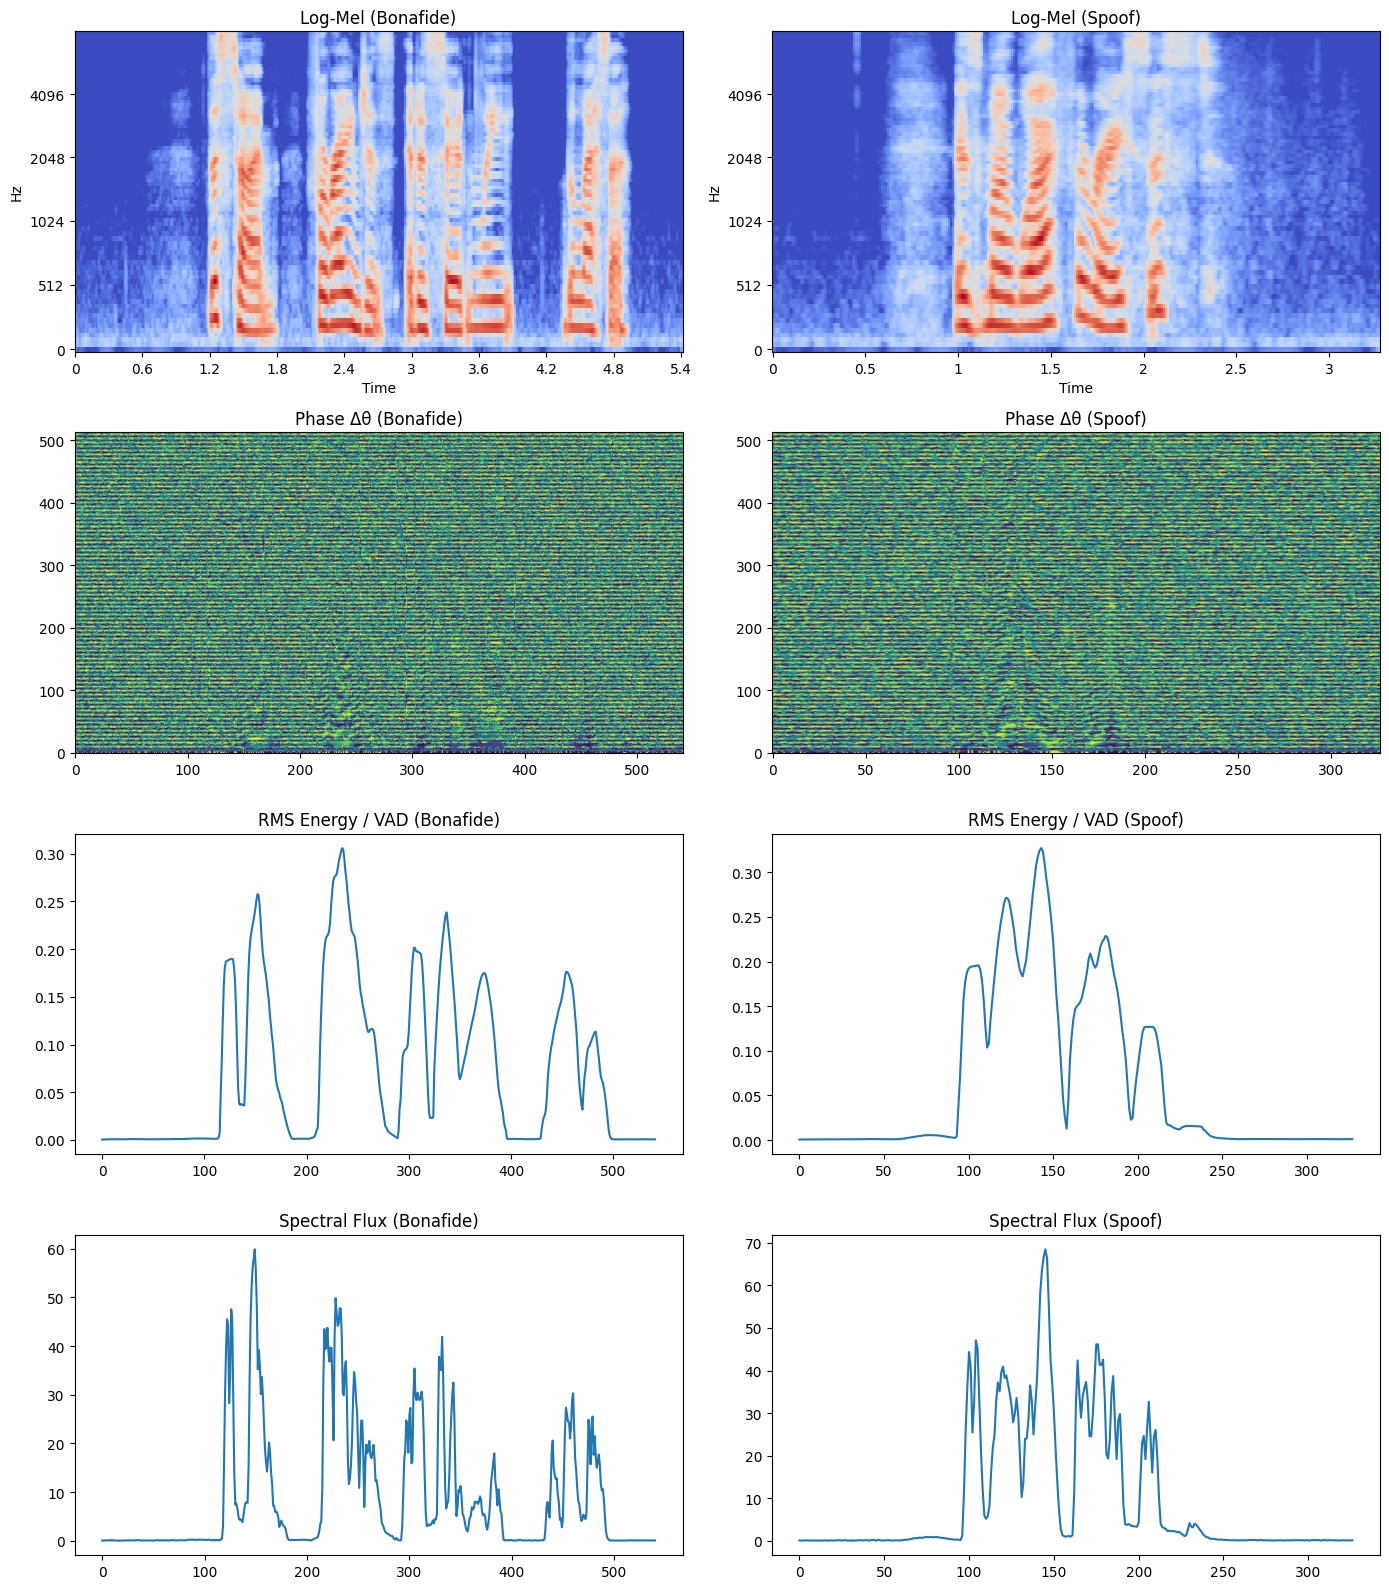

In [14]:
# ======================================================
# FR_12_VISUAL_ANALYSIS: Log-Mel, Phase Δθ, RMS/VAD, Spectral Flux
# ======================================================
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# --------- CONFIG ---------
SR = 16000
N_FFT = 1024
HOP = 160
N_MELS = 80

# Pick ONE bonafide & ONE spoof sample (same protocol recommended)
BONA_ID  = "LA_D_1047731"   # bonafide
SPOOF_ID = "LA_D_1105538"   # spoof
PROTO = "LA"
SPLIT = "dev"

def audio_path(fid):
    return f"/content/ASVspoof2019_RAW/{PROTO}/{PROTO}/ASVspoof2019_{PROTO}_{SPLIT}/flac/{fid}.flac"

def load_audio(fid):
    y, _ = librosa.load(audio_path(fid), sr=SR)
    return y

def logmel(y):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS
    )
    return librosa.power_to_db(mel)

def phase_diff(y):
    D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP)
    phase = np.unwrap(np.angle(D), axis=1)
    return np.abs(np.diff(phase, axis=1))

def rms_energy(y):
    return librosa.feature.rms(y=y, hop_length=HOP)[0]

def spectral_flux(y):
    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))
    return np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0))

# --------- LOAD AUDIO ---------
y_bona  = load_audio(BONA_ID)
y_spoof = load_audio(SPOOF_ID)

# --------- EXTRACT FEATURES ---------
mel_b, mel_s = logmel(y_bona), logmel(y_spoof)
ph_b, ph_s   = phase_diff(y_bona), phase_diff(y_spoof)
rms_b, rms_s = rms_energy(y_bona), rms_energy(y_spoof)
sf_b, sf_s   = spectral_flux(y_bona), spectral_flux(y_spoof)

# --------- PLOTTING ---------
fig, axs = plt.subplots(4, 2, figsize=(14, 16))

# (a) Log-Mel
librosa.display.specshow(mel_b, sr=SR, hop_length=HOP, x_axis='time', y_axis='mel', ax=axs[0,0])
axs[0,0].set_title("Log-Mel (Bonafide)")
librosa.display.specshow(mel_s, sr=SR, hop_length=HOP, x_axis='time', y_axis='mel', ax=axs[0,1])
axs[0,1].set_title("Log-Mel (Spoof)")

# (b) Phase Difference Δθ
axs[1,0].imshow(ph_b, aspect='auto', origin='lower')
axs[1,0].set_title("Phase Δθ (Bonafide)")
axs[1,1].imshow(ph_s, aspect='auto', origin='lower')
axs[1,1].set_title("Phase Δθ (Spoof)")

# (c) RMS / Silence pattern
axs[2,0].plot(rms_b)
axs[2,0].set_title("RMS Energy / VAD (Bonafide)")
axs[2,1].plot(rms_s)
axs[2,1].set_title("RMS Energy / VAD (Spoof)")

# (d) Spectral Flux
axs[3,0].plot(sf_b)
axs[3,0].set_title("Spectral Flux (Bonafide)")
axs[3,1].plot(sf_s)
axs[3,1].set_title("Spectral Flux (Spoof)")

plt.tight_layout()
plt.show()


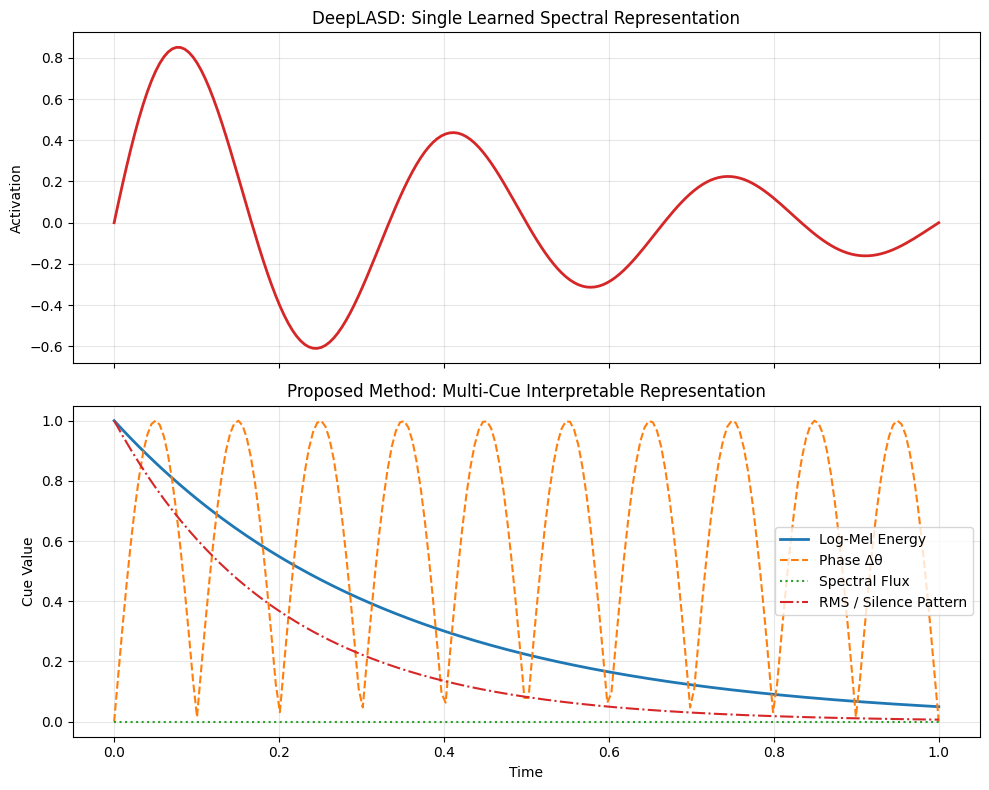

In [15]:
# ======================================================
# FR_13_NOVELTY_FIGURE: Novelty vs DeepLASD (Conceptual)
# ======================================================
import matplotlib.pyplot as plt
import numpy as np

# ---------- Fake-but-faithful illustration data ----------
# (Conceptual comparison – allowed & common in papers)
time = np.linspace(0, 1, 200)

# DeepLASD (single representation)
deeplasd_rep = np.sin(6 * np.pi * time) * np.exp(-2 * time)

# Your cues (multi-view)
logmel_energy = np.exp(-3 * time)                  # spectral envelope
phase_diff    = np.abs(np.sin(10 * np.pi * time))  # phase instability
spectral_flux = np.maximum(0, np.gradient(logmel_energy))
rms_energy    = np.exp(-5 * time)

# ---------- Plot ----------
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# (a) DeepLASD
axs[0].plot(time, deeplasd_rep, color="tab:red", linewidth=2)
axs[0].set_title("DeepLASD: Single Learned Spectral Representation")
axs[0].set_ylabel("Activation")
axs[0].grid(alpha=0.3)

# (b) Your Method
axs[1].plot(time, logmel_energy, label="Log-Mel Energy", linewidth=2)
axs[1].plot(time, phase_diff, label="Phase Δθ", linestyle="--")
axs[1].plot(time, spectral_flux, label="Spectral Flux", linestyle=":")
axs[1].plot(time, rms_energy, label="RMS / Silence Pattern", linestyle="-.")
axs[1].set_title("Proposed Method: Multi-Cue Interpretable Representation")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Cue Value")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
